In [ ]:
# import pyreadr
# import pandas as pd

# # 1. 读取 RData 文件
# # 替换为你实际的文件名
# # input_file = '/path/to/Tennessee_Eastman_Process/TEP_FaultFree_Testing.RData'
# # output_file = '/path/to/Tennessee_Eastman_Process/TEP_FaultFree_Testing.csv'

# input_file = '/path/to/Tennessee_Eastman_Process/TEP_FaultFree_Training.RData'
# output_file = '/path/to/Tennessee_Eastman_Process/TEP_FaultFree_Training.csv'

# print(f"正在读取 {input_file}...")
# result = pyreadr.read_r(input_file)

# # 2. 提取数据对象
# # RData 内部可能包含多个对象，我们查看键名
# keys = list(result.keys())
# print(f"检测到数据对象: {keys}")

# # 提取主数据（通常 keys[0] 就是我们要的表格）
# df = result[keys[0]]

# # 3. 转换为 CSV
# print(f"正在保存为 {output_file}...")
# df.to_csv(output_file, index=False)

# print("转换完成！")

In [ ]:
import pandas as pd
import polars as pl


df = pl.read_csv('/path/to/Tennessee_Eastman_Process/TEP_FaultFree_Testing.csv').to_pandas()
df.head(10), df.shape

(   faultNumber  simulationRun  sample  xmeas_1  xmeas_2  xmeas_3  xmeas_4  \
 0            0            1.0       1  0.25171   3672.4   4466.3   9.5122   
 1            0            1.0       2  0.25234   3642.2   4568.7   9.4145   
 2            0            1.0       3  0.24840   3643.1   4507.5   9.2901   
 3            0            1.0       4  0.25153   3628.3   4519.3   9.3347   
 4            0            1.0       5  0.21763   3655.8   4571.0   9.3087   
 5            0            1.0       6  0.21926   3646.8   4478.2   9.4460   
 6            0            1.0       7  0.22502   3709.6   4514.4   9.2249   
 7            0            1.0       8  0.22494   3690.7   4531.7   9.4079   
 8            0            1.0       9  0.23702   3675.8   4484.0   9.2437   
 9            0            1.0      10  0.23530   3668.0   4527.3   9.3643   
 
    xmeas_5  xmeas_6  xmeas_7  ...   xmv_2   xmv_3   xmv_4   xmv_5   xmv_6  \
 0   27.057   42.473   2705.6  ...  54.494  24.527  59.710  22

In [2]:
xmeas_list = [
    # --- 进料系统 (决定物料平衡的输入端) ---
    "xmeas_1",  # A 进料流量 (Stream 1): 主要反应原料 A 的实时输入量
    "xmeas_2",  # D 进料流量 (Stream 2): 主要反应原料 D 的实时输入量
    "xmeas_3",  # E 进料流量 (Stream 3): 主要反应原料 E 的实时输入量
    "xmeas_4",  # A+C 进料流量 (Stream 4): 包含循环气成分的混合进料
    "xmeas_5",  # 循环流量 (Stream 8): 反应器未反应气体的循环量
    "xmeas_6",  # 反应器进料速率 (Stream 6): 真正进入反应器的总物料流速

    # --- 核心反应器状态 (决定反应动力学的关键变量) ---
    "xmeas_7",  # 反应器压力: 压力越高通常反应越快，但也伴随安全风险 (核心输入)
    "xmeas_8",  # 反应器液位: 反应器内液相的持液量，影响停留时间
    "xmeas_9",  # 反应器温度: 影响化学平衡和产物选择性的最关键参数 (核心输入)

    # --- 分离与净化系统 (影响最终产率的中间环节) ---
    "xmeas_10", # 吹扫速率 (Stream 9): 排除惰性气体和副产物的排气流量
    "xmeas_11", # 分离器温度: 影响冷凝效果，决定气液分离效率
    "xmeas_12", # 分离器液位: 缓冲槽液位高度
    "xmeas_13", # 分离器压力: 气液分离过程的操作压力
    "xmeas_14", # 分离器底流 (Stream 10): 从分离器排向汽提塔的液体量
    "xmeas_15", # 汽提塔液位: 汽提塔底部液位持存
    "xmeas_16", # 汽提塔压力: 汽提塔操作压力
    "xmeas_17", # 汽提塔底流 (Stream 11): 产品流出速率

    # --- 关键过程变量（非回归目标） ---
    "xmeas_18", # 汽提塔温度: 影响轻组分脱除效率的关键变量
    "xmeas_19", # 汽提塔蒸汽流量: 维持提纯所需的能量输入
    "xmeas_20", # 压缩机功耗: 循环气体压缩所需的电力消耗 (成本指标)
    "xmeas_21", # 反应器冷却水出口温度: 反映反应放热强度的间接指标
    "xmeas_22", # 分离器冷却水出口温度: 反映冷凝负荷的指标

    # --- 组分分析 (实验室分析/在线色谱，采样频率低) ---
    "xmeas_23", # 进料中成分 A 浓度
    "xmeas_24", # 进料中成分 B 浓度
    "xmeas_25", # 进料中成分 C 浓度
    "xmeas_26", # 进料中成分 D 浓度
    "xmeas_27", # 进料中成分 E 浓度
    "xmeas_28", # 进料中成分 F 浓度
    "xmeas_29", # 吹扫气中成分 A 浓度
    "xmeas_30", # 吹扫气中成分 B 浓度
    "xmeas_31", # 吹扫气中成分 C 浓度
    "xmeas_32", # 吹扫气中成分 D 浓度
    "xmeas_33", # 吹扫气中成分 E 浓度
    "xmeas_34", # 吹扫气中成分 F 浓度
    "xmeas_35", # 吹扫气中成分 G 浓度
    "xmeas_36", # 吹扫气中成分 H 浓度
    "xmeas_37", # 产品流 (Stream 11) 中 D 组分浓度
    "xmeas_38", # 产品流 (Stream 11) 中 E 组分浓度
    "xmeas_39", # 产品流 (Stream 11) 中 F 组分浓度
    "xmeas_40", # 产品流 (Stream 11) 中 G 组分浓度: 产品关键质量指标 (回归目标 Y2)
    "xmeas_41"  # 产品流 (Stream 11) 中 H 组分浓度: 产品关键质量指标 (回归目标 Y3)
]

xmv_list = [
    "xmv_1",  # D 进料阀门开度: 调节原料 D 的输入速度
    "xmv_2",  # E 进料阀门开度: 调节原料 E 的输入速度
    "xmv_3",  # A 进料阀门开度: 调节原料 A 的输入速度
    "xmv_4",  # A+C 进料总阀开度: 调节总进料负荷
    "xmv_5",  # 压缩机循环阀开度: 调节系统循环比
    "xmv_6",  # 吹扫阀开度: 调节废气排放量，平衡系统压力
    "xmv_7",  # 分离器液位调节阀: 维持分离器液位平稳
    "xmv_8",  # 汽提塔液位调节阀: 维持汽提塔液位，直接影响出料量
    "xmv_9",  # 汽提塔蒸汽阀开度: 调节加热强度，影响能耗和纯度
    "xmv_10", # 反应器冷却水阀: 控制反应温度的最直接手段
    "xmv_11"  # 冷凝器冷却水阀: 控制气液分离效率
]

len_all = len(xmeas_list) + len(xmv_list)
print(len_all)

52


(480000,) 0     53.724
1     53.724
2     53.724
3     53.724
4     53.724
5     54.010
6     54.010
7     54.010
8     54.010
9     54.010
10    53.633
11    53.633
12    53.633
13    53.633
14    53.633
15    53.806
16    53.806
17    53.806
18    53.806
19    53.806
20    54.270
21    54.270
22    54.270
23    54.270
24    54.270
25    52.739
26    52.739
27    52.739
28    52.739
29    52.739
30    53.709
31    53.709
32    53.709
33    53.709
34    53.709
35    54.026
36    54.026
37    54.026
38    54.026
39    54.026
40    53.517
41    53.517
42    53.517
43    53.517
44    53.517
45    54.073
46    54.073
47    54.073
48    54.073
49    54.073
Name: xmeas_40, dtype: float64
(480000,) 0     43.828
1     43.828
2     43.828
3     43.828
4     43.828
5     43.398
6     43.398
7     43.398
8     43.398
9     43.398
10    44.748
11    44.748
12    44.748
13    44.748
14    44.748
15    44.425
16    44.425
17    44.425
18    44.425
19    44.425
20    43.640
21    43.640
22    43.640


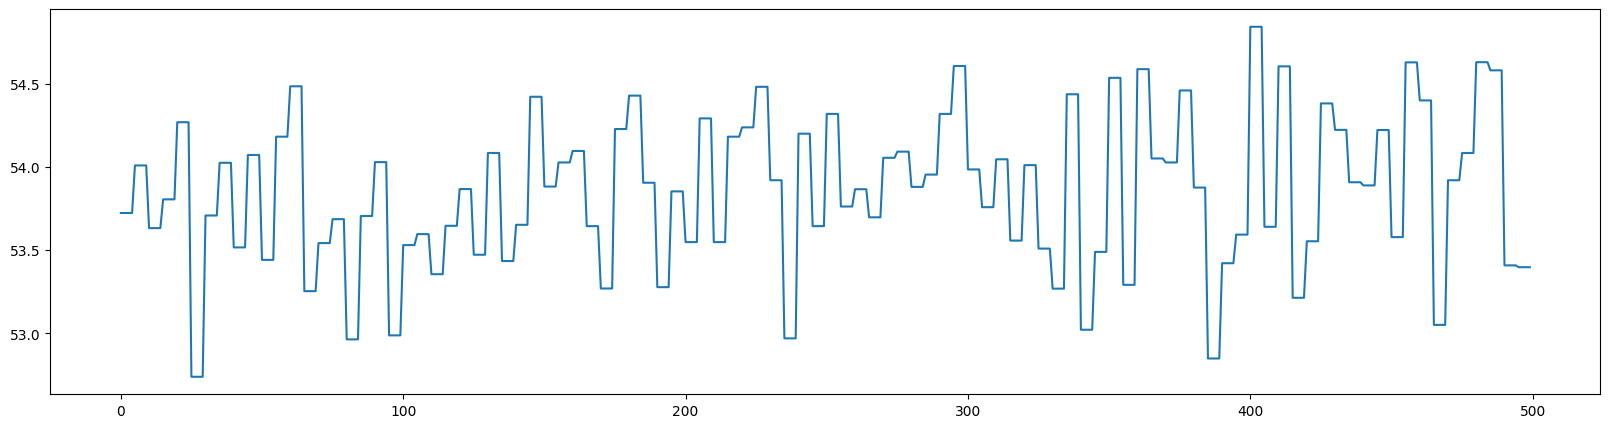

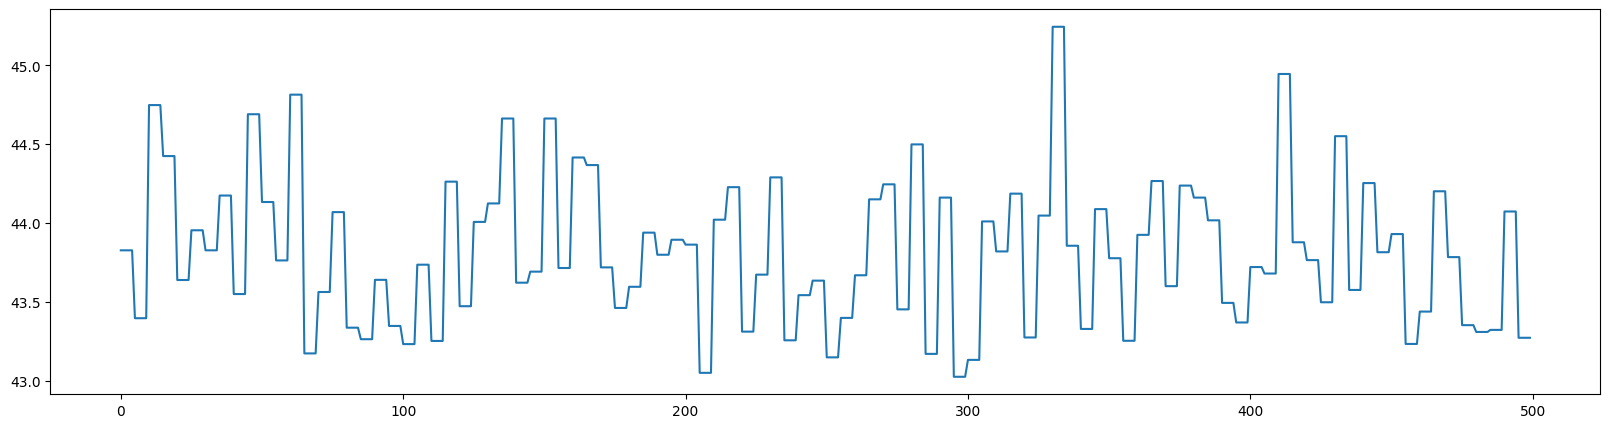

In [3]:
import matplotlib.pyplot as plt
data_chosen = df['xmeas_40']
print(data_chosen.shape, data_chosen[:50])

plt.figure(figsize=(20, 5))
plt.plot(data_chosen[:500])

data_chosen = df['xmeas_41']
print(data_chosen.shape, data_chosen[:50])

plt.figure(figsize=(20, 5))
plt.plot(data_chosen[:500])

In [4]:
# 定义你的估计器输入
input_features = [
    "xmeas_1", 
    "xmeas_2", 
    "xmeas_3", 
    "xmeas_4", 
    "xmeas_5", 
    "xmeas_6", 
    "xmeas_7", 
    "xmeas_8",  
    "xmeas_9",  
    "xmeas_10", 
    "xmeas_11", 
    "xmeas_12", 
    "xmeas_13", 
    "xmeas_14", 
    "xmeas_15", 
    "xmeas_16", 
    "xmeas_17", 
    "xmeas_18", 
    "xmeas_19", 
    "xmeas_20", 
    "xmeas_21", 
    "xmeas_22", 
    "xmv_1", 
    "xmv_2", 
    "xmv_3", 
    "xmv_4", 
    "xmv_5",  
    "xmv_6",
    "xmv_7", 
    "xmv_8", 
    "xmv_9",
    "xmv_10",
    "xmv_11"
]

# 定义你的回归目标
target_columns = ["xmeas_40", "xmeas_41"]

# 假设 df 是你转换出来的 CSV 数据
X = df[input_features]
y = df[target_columns]

In [ ]:
# ===== 混合输入构造：保留关键时序为 NPZ + 文本变量按模板转自然语言（不调用API） =====
import json
import numpy as np

# 你可按需调整这些参数
WINDOW_SIZE = 96
STEP = 5
OUTPUT_NPZ = f"/path/to/regress_data/tes_regression_seq{WINDOW_SIZE}_pred1_test.npz"
OUTPUT_JSON = f"/path/to/regress_data/tes_regression_seq{WINDOW_SIZE}_pred1_test.json"
TEXT_LANG = "en"  # "zh" 或 "en"


# 按前面建议分组
keep_ts_features = [
    "xmeas_1", "xmeas_2", "xmeas_3", "xmeas_4", "xmeas_5", "xmeas_6",
    "xmeas_7", "xmeas_8", "xmeas_9", "xmeas_10", "xmeas_11",
    "xmeas_13", "xmeas_16", "xmeas_17", "xmeas_18", "xmeas_19",
    "xmv_9", "xmv_10", "xmv_11"
]
text_features = [
    "xmv_1", "xmv_2", "xmv_3", "xmv_4", "xmv_5", "xmv_6", "xmv_7", "xmv_8",
    "xmeas_12", "xmeas_14", "xmeas_15", "xmeas_20", "xmeas_21", "xmeas_22"
]

# 基础校验
assert set(keep_ts_features).isdisjoint(set(text_features)), "keep_ts_features 与 text_features 不能有重叠。"
missing_keep = [c for c in keep_ts_features if c not in df.columns]
missing_text = [c for c in text_features if c not in df.columns]
missing_targets = [c for c in target_columns if c not in df.columns]
assert not missing_keep, f"keep_ts_features 缺失列: {missing_keep}"
assert not missing_text, f"text_features 缺失列: {missing_text}"
assert not missing_targets, f"target_columns 缺失列: {missing_targets}"


def summarize_window(arr: np.ndarray):
    """arr: [WINDOW_SIZE]，内部统计仅用于判别，不写入最终JSON。"""
    diff = np.diff(arr)
    trend_delta = float(arr[-1] - arr[0])
    slope = trend_delta / max(len(arr) - 1, 1)
    step_thr = max(1e-6, 0.5 * float(np.std(diff)))
    step_changes = int(np.sum(np.abs(diff) > step_thr))
    volatility = float(np.std(diff))

    if slope > 0:
        trend = "上升"
    elif slope < 0:
        trend = "下降"
    else:
        trend = "平稳"

    return {
        "last": float(arr[-1]),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "trend": trend,
        "trend_delta": trend_delta,
        "volatility": volatility,
        "step_changes": step_changes,
    }


def _level_by_ratio(v: float, t1: float, t2: float):
    if v < t1:
        return "低"
    if v < t2:
        return "中"
    return "高"


def summarize_to_text_line(feat: str, s: dict):
    """
    将统计量转成单行模板文本。
    支持中英文切换：TEXT_LANG in {"zh", "en"}
    """
    eps = 1e-6
    mean_abs = abs(s["mean"]) + eps

    # 相对离散程度（尺度无关）
    cv_std = s["std"] / mean_abs
    dispersion_level = _level_by_ratio(cv_std, 0.005, 0.02)

    # 相对波动强度（尺度无关）
    cv_vol = s["volatility"] / mean_abs
    volatility_level = _level_by_ratio(cv_vol, 0.005, 0.02)

    # 幅度范围（尺度无关）
    range_ratio = (s["max"] - s["min"]) / mean_abs
    range_level = _level_by_ratio(range_ratio, 0.01, 0.05)

    # 趋势强弱：位移对比标准差
    trend_strength = abs(s["trend_delta"]) / (s["std"] + eps)
    if trend_strength < 0.5:
        trend_strength_text = "趋势不明显"
    elif trend_strength < 1.5:
        trend_strength_text = "趋势缓慢"
    else:
        trend_strength_text = "趋势明显"

    # 变化/调节动作频度
    ratio = s["step_changes"] / max(WINDOW_SIZE - 1, 1)
    if ratio < 0.3:
        action_level = "稀疏"
    elif ratio < 0.6:
        action_level = "中等"
    else:
        action_level = "频繁"

    if TEXT_LANG.lower() == "en":
        trend_map = {"上升": "rising", "下降": "falling", "平稳": "stable"}
        level_map = {"低": "low", "中": "medium", "高": "high"}
        trend_strength_map = {
            "趋势不明显": "weak trend",
            "趋势缓慢": "moderate trend",
            "趋势明显": "strong trend",
        }
        action_map = {"稀疏": "sparse", "中等": "moderate", "频繁": "frequent"}

        trend_en = trend_map.get(s["trend"], "stable")
        dispersion_en = level_map.get(dispersion_level, "medium")
        volatility_en = level_map.get(volatility_level, "medium")
        range_en = level_map.get(range_level, "medium")
        trend_strength_en = trend_strength_map.get(trend_strength_text, "moderate trend")
        action_en = action_map.get(action_level, "moderate")

        return (
            f"{feat}: last {round(float(s['last']), 1):.1f}, mean {round(float(s['mean']), 1):.1f}; "
            f"overall {trend_en}, {trend_strength_en} (delta {round(float(s['trend_delta']), 1):.1f}); "
            f"volatility {volatility_en} (value {round(float(s['volatility']), 1):.1f}), "
            f"dispersion {dispersion_en} (std {round(float(s['std']), 1):.1f}), "
            f"range change {range_en} (min {round(float(s['min']), 1):.1f}, max {round(float(s['max']), 1):.1f}), "
            f"change rhythm {action_en} (step changes {round(float(s['step_changes']), 1):.1f})."
        )

    return (
        f"{feat}：末值{round(float(s['last']), 1):.1f}，均值{round(float(s['mean']), 1):.1f}；"
        f"整体{s['trend']}，{trend_strength_text}（位移{round(float(s['trend_delta']), 1):.1f}）；"
        f"波动{volatility_level}（波动值{round(float(s['volatility']), 1):.1f}），"
        f"离散{dispersion_level}（标准差{round(float(s['std']), 1):.1f}），"
        f"区间变化{range_level}（最小值{round(float(s['min']), 1):.1f}，最大值{round(float(s['max']), 1):.1f}），"
        f"变化节奏{action_level}（步变次数{round(float(s['step_changes']), 1):.1f}）。"
    )


# 分组与排序（避免跨工况/跨仿真拼窗）
group_cols = [c for c in ["faultNumber", "simulationRun"] if c in df.columns]
sort_cols = group_cols + (["sample"] if "sample" in df.columns else [])
df_sorted = df.sort_values(sort_cols).reset_index(drop=True) if sort_cols else df.reset_index(drop=True)
grouped = df_sorted.groupby(group_cols, sort=False) if group_cols else [("__all__", df_sorted)]

# 构造样本
X_ts_list = []
y_list = []
meta_list = []
json_records = []

sample_id = 0

for gid, g in grouped:
    g = g.reset_index(drop=True)
    n = len(g)
    if n <= WINDOW_SIZE:
        continue

    for start in range(0, n - WINDOW_SIZE, STEP):
        target_idx = start + WINDOW_SIZE

        # 1) 保留时序输入
        X_ts = g.loc[start:target_idx - 1, keep_ts_features].to_numpy(dtype=np.float32)  # [W, F_keep]
        y_target = g.loc[target_idx, target_columns].to_numpy(dtype=np.float32)            # [2]

        # 2) 文本变量 -> 单行模板文本（不保留原始摘要数字）
        lines = []
        for feat in text_features:
            arr = g.loc[start:target_idx - 1, feat].to_numpy(dtype=np.float32)
            stats = summarize_window(arr)
            lines.append(summarize_to_text_line(feat, stats))
        text_block = "\n".join(lines)


        # # 3) meta
        # if group_cols:
        #     gid_tuple = gid if isinstance(gid, tuple) else (gid,)
        #     gid_map = dict(zip(group_cols, gid_tuple))
        #     # fault_num = int(gid_map.get("faultNumber", -1))
        #     # sim_run = int(float(gid_map.get("simulationRun", -1)))
        # else:
        #     fault_num = -1
        #     sim_run = -1

        meta_info = {
            # "faultNumber": fault_num,
            # "simulationRun": sim_run,
            "start": int(start), "end": int(target_idx - 1), "target_index": int(target_idx),
        }

        # 4) 收集
        X_ts_list.append(X_ts)
        y_list.append(y_target)
        # meta_list.append([fault_num, sim_run, int(start), int(target_idx - 1), int(target_idx)])
        meta_list.append([int(start), int(target_idx - 1), int(target_idx)])

        json_records.append({
            "sample_id": int(sample_id),
            "meta": meta_info,
            # "target_columns": list(target_columns),
            "text_description": text_block,
        })

        sample_id += 1

assert len(X_ts_list) > 0, "未构造出任何样本，请检查 WINDOW_SIZE/STEP 或分组列。"

# 存 NPZ（时序保留）
X_ts = np.stack(X_ts_list, axis=0).astype(np.float32)   # [N, W, F_keep]
y = np.stack(y_list, axis=0).astype(np.float32)         # [N, 2]
meta = np.asarray(meta_list, dtype=np.int32)            # [N, 5]

np.savez_compressed(
    OUTPUT_NPZ,
    X_ts=X_ts,
    y=y,
    meta=meta,
    keep_ts_features=np.asarray(keep_ts_features, dtype=object),
    text_features=np.asarray(text_features, dtype=object),
    target_columns=np.asarray(target_columns, dtype=object),
    window_size=np.int32(WINDOW_SIZE),
    step=np.int32(STEP),
)

# 存 JSON（与 NPZ 一一对应，sample_id 对齐）
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    if TEXT_LANG == "en":
        json.dump({
            "num_samples": int(len(json_records)),
            # "npz_path": OUTPUT_NPZ,
            "schema": {
                "sample_id": "corresponds one-to-one with the sample at index `sample_id` in the NPZ file",
                "meta": "start/end/target_index",
                "target_columns": "target_columns:['xmeas_40', 'xmeas_41']",
                "text_description": "textual description of additional contextual information",
                "background description": "This task is based on process data from the Tennessee Eastman Process (TEP). This process comprises various units—including feed systems, reactors, separators, strippers, and recycle/cooling loops—and is characterized by significant coupling, time delays, and nonlinearities among its variables. The inputs utilized in this study consist of 33 process variables: 22 measured variables (xmeas_1 through xmeas_22) and 11 manipulated variables (xmv_1 through xmv_11). These variables capture critical operational information, such as material flows, temperatures, pressures, liquid levels, energy consumption, and valve positions. The target variables are key quality metrics for the product stream components: xmeas_40 (Component G concentration) and xmeas_41 (Component H concentration). Fundamentally, this task constitutes a multivariate dynamic soft-sensing problem: leveraging easily measurable process variables to estimate product quality attributes that are difficult to measure or subject to significant measurement delays.",
                "task_definition":"Given one sample, predict next-step product quality using two inputs: (1) time-series window (L=96) of key variables, (2) one-line-per-variable text summaries for remaining variables (trend/fluctuation/change rate); targets: `xmeas_40`,`xmeas_41`; output must be JSON only, no explanation/units/extra fields, fixed schema: {\"xmeas_40\": <float>, \"xmeas_41\": <float>}; both output values must be rounded to 2 decimal places.",
                "variable_description": "xmeas_1~xmeas_4 (Feed flows for A, D, E, and A+C) characterize the total raw material input load and ratio; xmeas_5~xmeas_6 (Recycle flow and reactor feed rate) characterize the reflux intensity and reactor inlet load; xmeas_7~xmeas_9 (Reactor pressure, liquid level, and temperature) characterize reaction kinetics as well as thermal and residence states; xmeas_10~xmeas_14 (Purge rate, separator temperature/liquid level/pressure, and separator bottoms flow) characterize the gas-liquid equilibrium and stream distribution within the separation section; xmeas_15~xmeas_19 (Stripper liquid level/pressure/bottoms flow/temperature, and steam flow) characterize the stripping intensity and operational status of the column section; xmeas_20~xmeas_22 (Compressor power consumption, and cooling water outlet temperatures for the reactor/separator) characterize energy consumption and heat exchange loads; xmv_1~xmv_4 (Feed valves for A, D, E, and A+C) are used for feed manipulation; xmv_5~xmv_6 (Recycle valve and purge valve) are used to balance reflux and discharge flows; xmv_7~xmv_8 (Separator/stripper liquid level valves) are used for liquid level loop control; xmv_9 (Stripper steam valve) is used to regulate stripping energy input; xmv_10~xmv_11 (Reactor/condenser cooling water valves) are used to adjust temperature and condensing capacity; the prediction targets are the values at the next time step for xmeas_40 (Component G concentration in the product) and xmeas_41 (Component H concentration in the product)."
            },
            "records": json_records,
        }, f, ensure_ascii=False, indent=2)
    elif TEXT_LANG == "zh":
        json.dump({
            "num_samples": int(len(json_records)),
            # "npz_path": OUTPUT_NPZ,
            "schema": {
                "sample_id": "与NPZ文件中索引为`sample_id`的样本一一对应",
                "meta": "start/end/target_index",
                "target_columns": "目标列：['xmeas_40', 'xmeas_41']",
                "text_description": "对额外上下文信息的文本描述",
                "background description": "该任务基于田纳西东曼过程（TEP）的过程数据。该过程包含多个单元——包括进料系统、反应器、分离器、汽提塔以及回流/冷却环路——其变量之间存在显著的耦合、时滞和非线性关系。此研究中使用的输入由33个过程变量组成：22个测量变量（xmeas_1至xmeas_22）和11个操作变量（xmv_1至xmv_11）。这些变量捕捉了关键的操作信息，如物料流量、温度、压力、液位、能耗和阀门位置。目标变量是产品流关键质量指标：xmeas_40（组分G浓度）和xmeas_41（组分H浓度）。从根本上讲，该任务构成了一个多变量动态软测量问题：利用易于测量的过程变量来估计难以测量或存在显著测量延迟的产品质量属性。",
                "task_definition":"给定一个样本，使用两类输入预测下一步产品质量： (1) 关键变量的时序窗口（长度=96），(2) 其余变量的单行文本总结（趋势/波动/变化率）；目标：`xmeas_40`,`xmeas_41`；输出必须仅为JSON，无解释/单位/额外字段，固定格式：{\"xmeas_40\": <float>, \"xmeas_41\": <float>}；两个输出数值必须保留2位小数。",
                "variable_description": "xmeas_1~xmeas_4（A、D、E和A+C的进料流量）表征了原料总输入负荷和比例；xmeas_5~xmeas_6（回流流量和反应器进料率）表征了回流强度和反应器进料负荷；xmeas_7~xmeas_9（反应器压力、液位和温度）表征了反应动力学以及热力学和停留状态；xmeas_10~xmeas_14（排放率、分离器温度/液位/压力和分离器底部流量）表征了气液平衡和分离 section 内的流体分布；xmeas_15~xmeas_19（汽提塔液位/压力/底部流量/温度和蒸汽流量）表征了汽提强度和塔 section 的操作状态；xmeas_20~xmeas_22（压缩机功率消耗和反应器/分离器冷却水出口温度）表征了能耗和换热负荷；xmv_1~xmv_4（A、D、E和A+C的进料阀门）用于进料操作；xmv_5~xmv_6（回流阀门和排放阀门）用于平衡回流和排放流量；xmv_7~xmv_8（分离器/汽提塔液位阀门）用于液位环路控制；xmv_9（汽提塔蒸汽阀门）用于调节汽提能量输入；xmv_10~xmv_11（反应器/冷凝器冷却水阀门）用于调整温度和冷凝能力；预测目标是下一时间步的 xmeas_40（产品中组分G浓度）和 xmeas_41（产品中组分H浓度）。"
            },
            "records": json_records,
        }, f, ensure_ascii=False, indent=2)

print(f"保存完成: {OUTPUT_NPZ}")
print(f"保存完成: {OUTPUT_JSON}")
print(f"X_ts shape = {X_ts.shape}, y shape = {y.shape}, meta shape = {meta.shape}")

# 打印一个示例给你检查
example_id = 0
print("\n===== 示例样本检查 =====")
print("sample_id:", json_records[example_id]["sample_id"])
print("meta:", json_records[example_id]["meta"])
print("target(y):", y[example_id].tolist())
print("keep_ts window shape:", X_ts[example_id].shape)
print("text_description:")
print(json_records[example_id]["text_description"])

In [7]:
json_records[0]

{'sample_id': 0,
 'meta': {'start': 0, 'end': 95, 'target_index': 96},
 'text_description': 'xmv_1: last 63.0, mean 63.1; overall rising, weak trend (delta 0.0); volatility medium (value 0.6), dispersion medium (std 0.6), range change medium (min 61.9, max 64.7), change rhythm frequent (step changes 57.0).\nxmv_2: last 53.8, mean 53.8; overall falling, moderate trend (delta -0.7); volatility medium (value 0.6), dispersion medium (std 0.5), range change medium (min 52.7, max 55.0), change rhythm frequent (step changes 59.0).\nxmv_3: last 25.8, mean 24.8; overall rising, weak trend (delta 1.3); volatility high (value 2.5), dispersion high (std 3.0), range change high (min 16.7, max 30.0), change rhythm moderate (step changes 30.0).\nxmv_4: last 61.8, mean 61.4; overall rising, strong trend (delta 2.1); volatility high (value 1.7), dispersion high (std 1.3), range change high (min 58.8, max 64.4), change rhythm frequent (step changes 57.0).\nxmv_5: last 22.4, mean 21.8; overall rising, we